c:\Users\Али Айнур\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PART 1: HONEST LOO CROSS-VALIDATION (NO LEAKAGE) + ALL MODELS (NO LINEAR, NO SUMMER)
Number of observations: 37
Snow season months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(10), np.int32(11), np.int32(12)]

HONEST LOO RESULTS (NO LEAKAGE, NO SUMMER) – NO LINEAR REGRESSION
ERA5           : MAE=19.8 mm, RMSE=26.0 mm, R²=0.746, KGE=0.814, MAPE=33.5%
Ridge          : MAE=21.8 mm, RMSE=29.9 mm, R²=0.663, KGE=0.827, MAPE=39.3%
Random Forest  : MAE=19.8 mm, RMSE=26.4 mm, R²=0.739, KGE=0.843, MAPE=35.8%
XGBoost        : MAE=19.1 mm, RMSE=24.7 mm, R²=0.771, KGE=0.857, MAPE=38.1%
CatBoost       : MAE=19.0 mm, RMSE=23.7 mm, R²=0.788, KGE=0.861, MAPE=32.6%
Ensemble       : MAE=18.2 mm, RMSE=23.8 mm, R²=0.787, KGE=0.864, MAPE=34.4%

✅ LOO metrics saved to 'tables/LOO_all_metrics_no_summer.csv'

PART 2: FINAL FORECAST 2022-2023 (without summer, without Linear Regression)
✅ Forecast saved to 'tables/forecast_2022_2023_no_summer.csv'

PART 3: PLOTS (continuous timelin

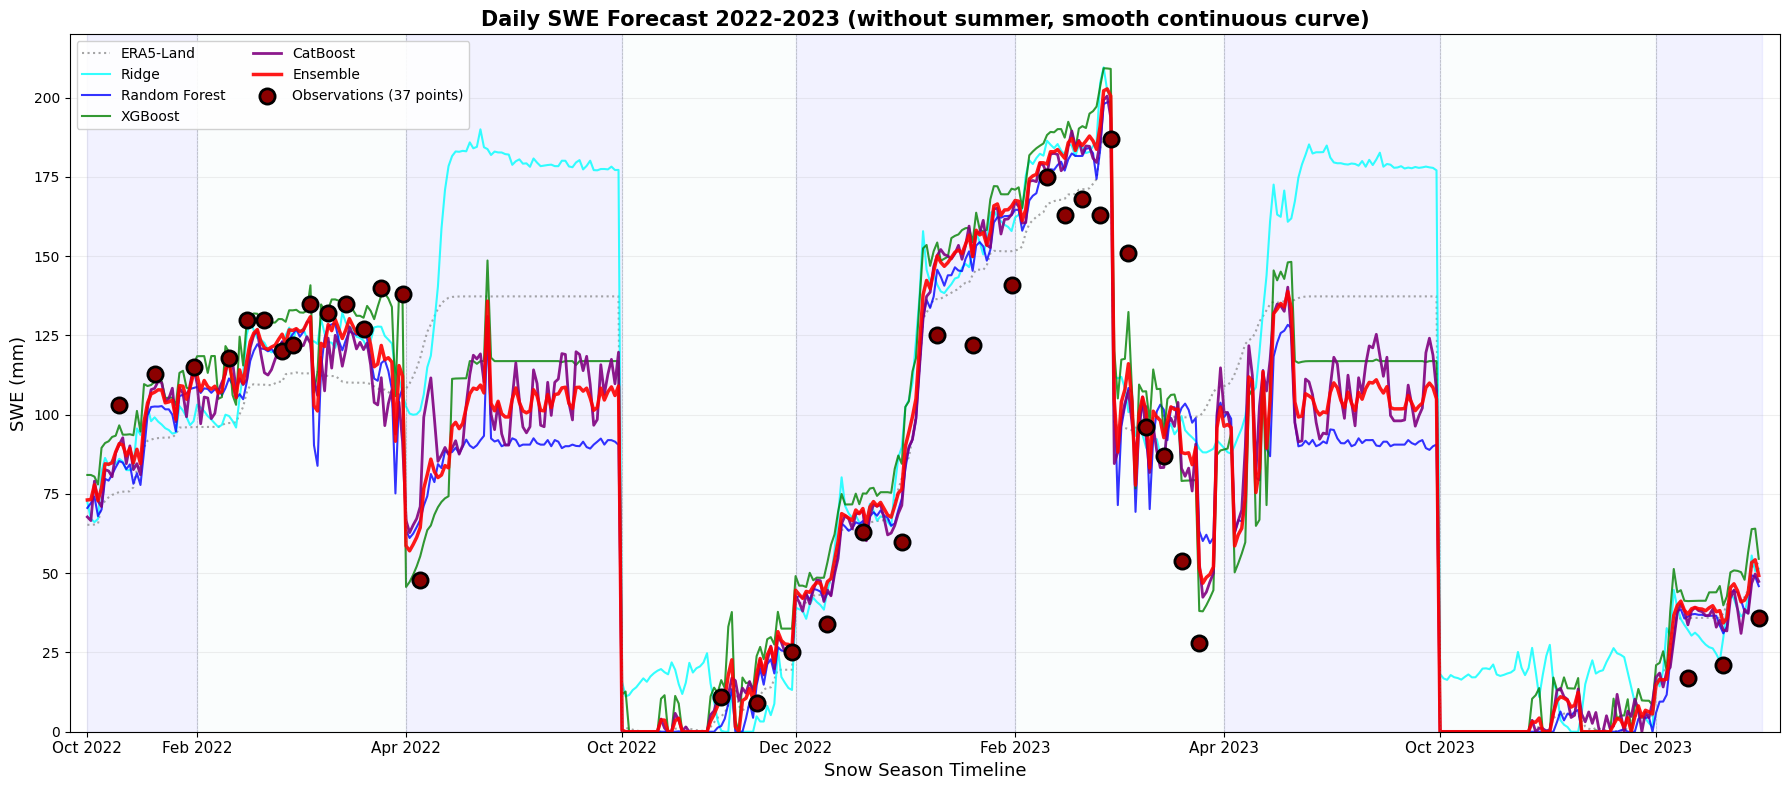

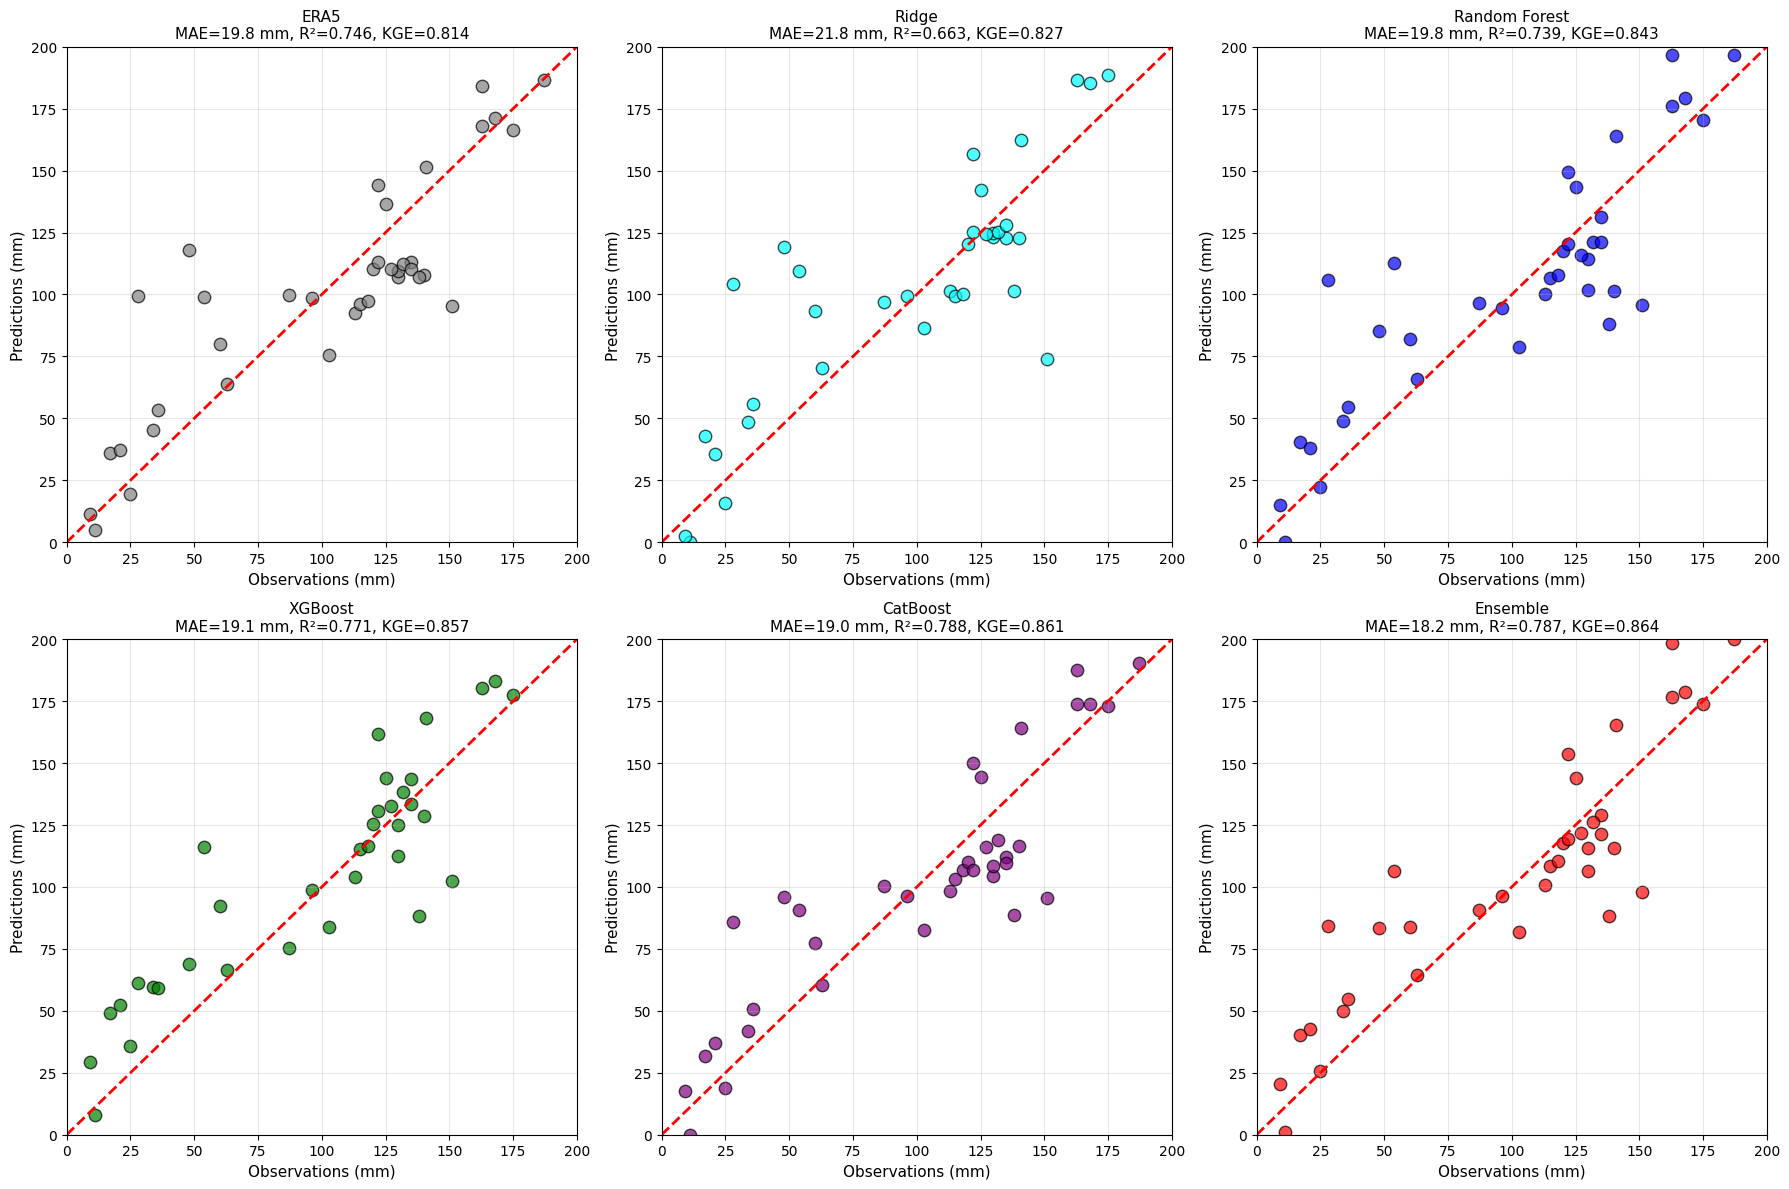

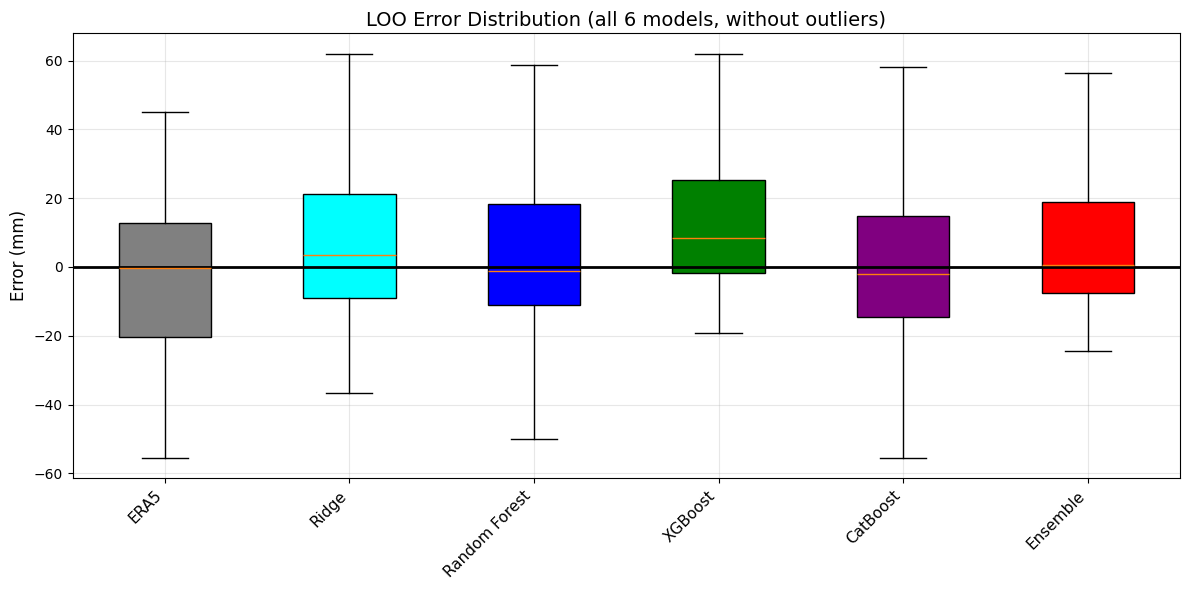

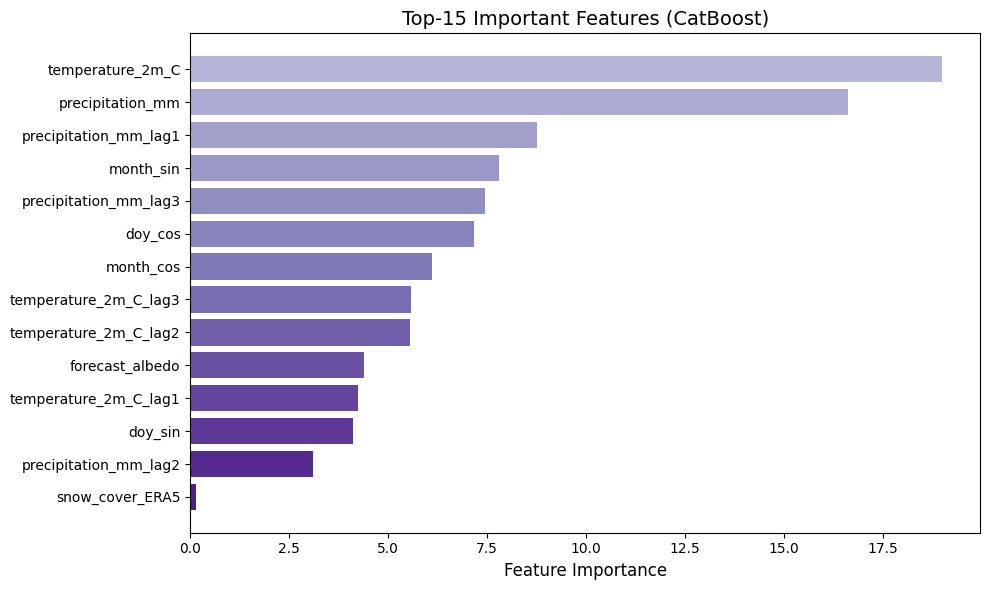


PART 4: SHAP ANALYSIS


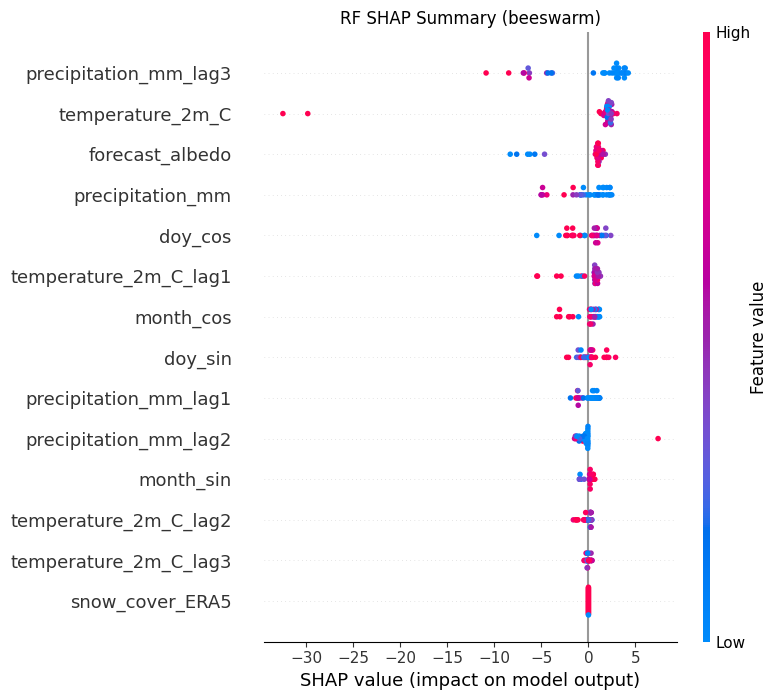

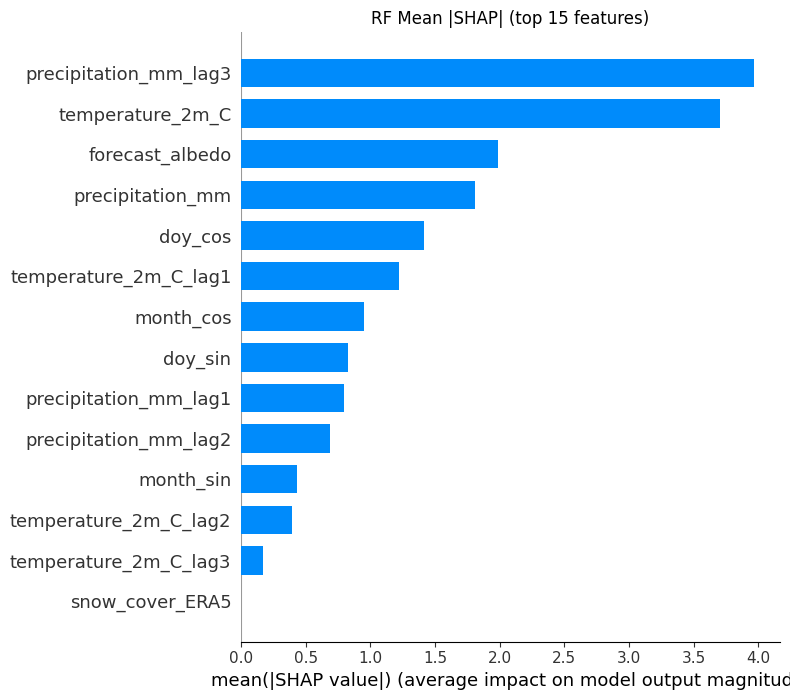

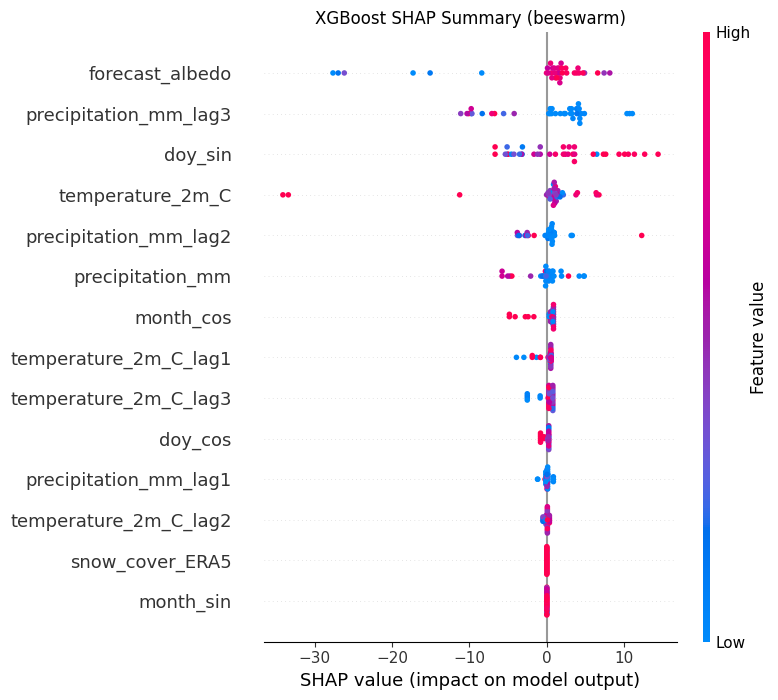

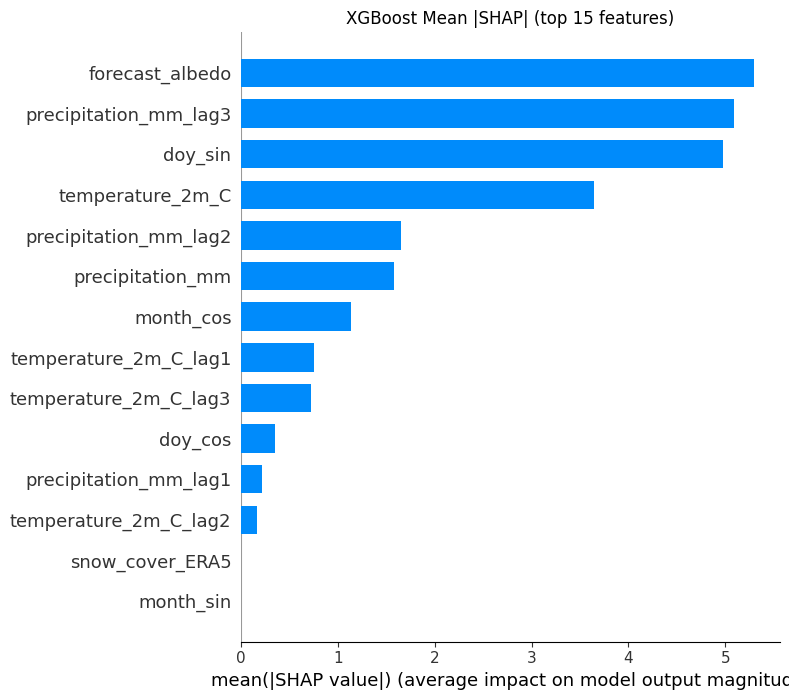

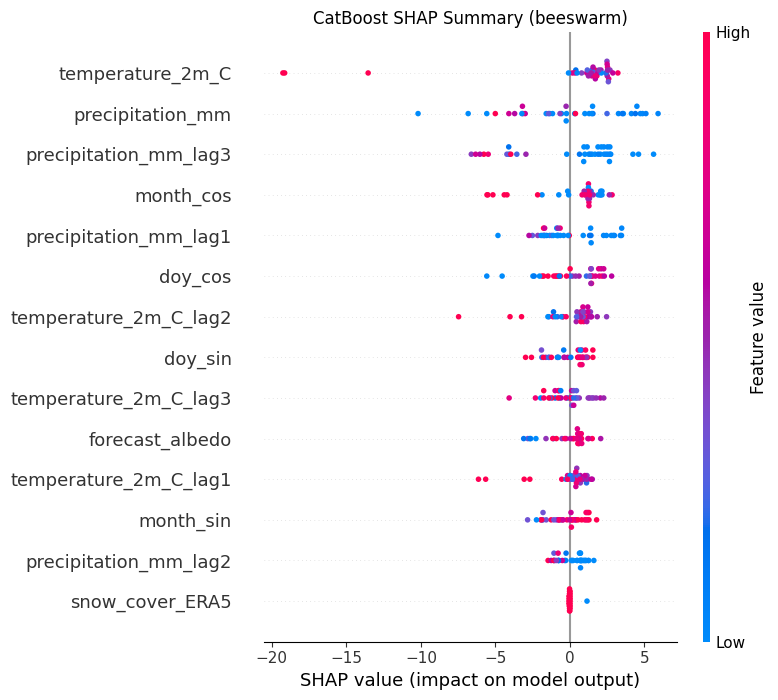

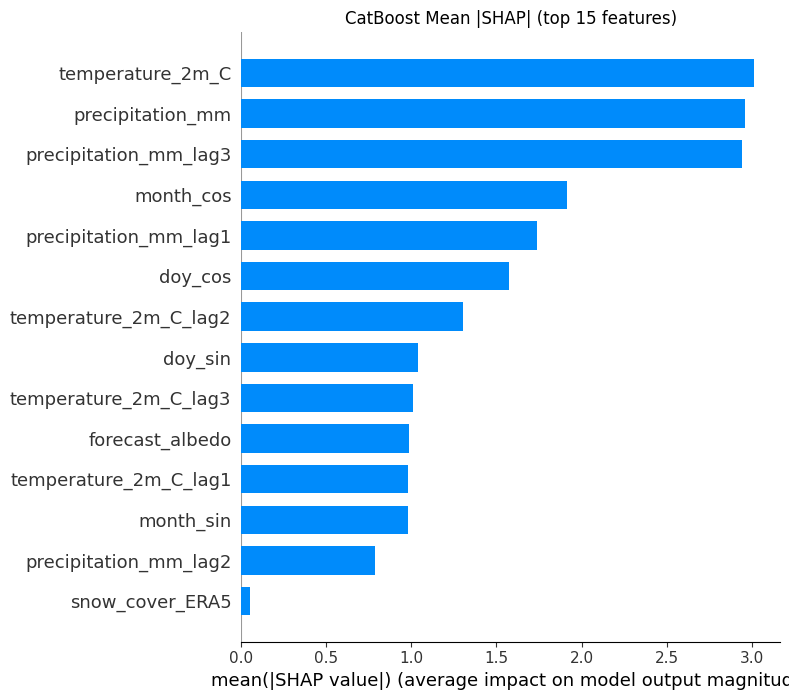


✅ DONE! Smooth continuous timeline, no gaps, no Linear Regression.
   Summer months removed, curves connect smoothly between seasons.


In [1]:
# ============================================================
# COMPLETE ANALYSIS: LOO + ALL MODELS + ALL METRICS + PLOTS + DAILY FORECAST
# Without Linear Regression, without summer months (6,7,8,9)
# CONTINUOUS TIMELINE (smooth transitions)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import shap
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# PATHS (adjust to your repository structure)
# ============================================================
DATA_PATH = '../../data_preprocessing/processed/shemonaikha_snow_dataset_2014_2023.csv'
OBS_PATH  = '../../data_preprocessing/data/shemonaikha.csv'
FIG_DIR   = 'figures/'
TABLE_DIR = 'tables/'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

print("=" * 80)
print("PART 1: HONEST LOO CROSS-VALIDATION (NO LEAKAGE) + ALL MODELS (NO LINEAR, NO SUMMER)")
print("=" * 80)

# ------------------------- 1. Data Loading -------------------------
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['era5_swe'] = df['swe_final']

df_station = pd.read_csv(OBS_PATH)
df_station['Date'] = df_station['Date'].astype(str).str.replace('"', '').str.strip()
df_station['Date'] = df_station['Date'].str.replace(',$', '', regex=True)
df_station['Date'] = pd.to_datetime(df_station['Date'], format='%d.%m.%Y %H:%M')
df_station['SWE'] = pd.to_numeric(df_station['SWE'].astype(str).str.replace('"', '').str.replace(',', ''), errors='coerce')
df_station['date'] = df_station['Date'].dt.date
df_station = df_station.drop_duplicates(subset=['date']).copy()
df_station['date'] = pd.to_datetime(df_station['date'])
station_dict = dict(zip(df_station['date'], df_station['SWE']))
df['target_swe'] = df['date'].map(station_dict)

# 2. Snow Season Only (no summer months 6,7,8,9)
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df_snow = df[~df['month'].isin([6, 7, 8, 9])].copy().reset_index(drop=True)

# Points with observations
df_obs = df_snow[df_snow['target_swe'].notna()].copy().reset_index(drop=True)
df_obs = df_obs.sort_values('date').reset_index(drop=True)

print(f"Number of observations: {len(df_obs)}")
print(f"Snow season months: {sorted(df_snow['month'].unique())}")

# 3. Feature Building Function
def build_features_for_df(df_subset, historical_context=None):
    df_out = df_subset.copy()
    df_out['doy'] = df_out['date'].dt.dayofyear
    df_out['doy_sin'] = np.sin(2 * np.pi * df_out['doy'] / 365)
    df_out['doy_cos'] = np.cos(2 * np.pi * df_out['doy'] / 365)
    df_out['month'] = df_out['date'].dt.month
    df_out['month_sin'] = np.sin(2 * np.pi * df_out['month'] / 12)
    df_out['month_cos'] = np.cos(2 * np.pi * df_out['month'] / 12)

    base_features = ['doy_sin', 'doy_cos', 'month_sin', 'month_cos',
                    'temperature_2m_C', 'precipitation_mm',
                    'snow_cover_ERA5', 'forecast_albedo']
    base_features = [f for f in base_features if f in df_out.columns]

    if historical_context is not None:
        for feat in ['temperature_2m_C', 'precipitation_mm']:
            if feat in df_out.columns:
                for lag in [1, 2, 3]:
                    col = f'{feat}_lag{lag}'
                    df_out[col] = historical_context.get(col, 0.0)
    else:
        for feat in ['temperature_2m_C', 'precipitation_mm']:
            if feat in df_out.columns:
                for lag in [1, 2, 3]:
                    col = f'{feat}_lag{lag}'
                    df_out[col] = df_out[feat].shift(lag)

    for col in base_features:
        if col in df_out.columns:
            df_out[col] = df_out[col].fillna(method='ffill').fillna(0)

    feature_cols = base_features.copy()
    for feat in ['temperature_2m_C', 'precipitation_mm']:
        if feat in df_out.columns:
            for lag in [1, 2, 3]:
                col = f'{feat}_lag{lag}'
                if col in df_out.columns:
                    feature_cols.append(col)

    X = df_out[feature_cols].values
    X = np.nan_to_num(X, nan=0.0)

    if len(df_out) > 0:
        last_row = df_out.iloc[-1]
        new_context = {}
        for col in feature_cols:
            if 'lag' not in col:
                new_context[col] = last_row[col] if not pd.isna(last_row[col]) else 0.0
        for feat in ['temperature_2m_C', 'precipitation_mm']:
            if feat in df_out.columns:
                cur_val = last_row[feat] if not pd.isna(last_row[feat]) else 0.0
                new_context[f'{feat}_lag3'] = new_context.get(f'{feat}_lag2', 0.0)
                new_context[f'{feat}_lag2'] = new_context.get(f'{feat}_lag1', 0.0)
                new_context[f'{feat}_lag1'] = cur_val
        return X, feature_cols, new_context
    else:
        return np.array([]), feature_cols, historical_context or {}

# 4. LOO Cross-Validation
n = len(df_obs)
indices = np.arange(n)
loo = LeaveOneOut()

y_true_loo = []
pred_era5_loo = []
pred_ridge_loo = []
pred_rf_loo = []
pred_xgb_loo = []
pred_cb_loo = []
pred_ens_loo = []
dates_loo = []

for train_idx, test_idx in loo.split(indices):
    train_df = df_obs.iloc[train_idx].copy().sort_values('date').reset_index(drop=True)
    test_row = df_obs.iloc[test_idx].iloc[0]

    X_train, feature_names, context = build_features_for_df(train_df)
    y_train = train_df['target_swe'].values
    era5_train = train_df['era5_swe'].values
    y_train_bias = y_train - era5_train

    test_df = pd.DataFrame([test_row])
    X_test, _, _ = build_features_for_df(test_df, historical_context=context)
    era5_test = test_row['era5_swe']

    # Ridge
    ridge = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=10.0))])
    ridge.fit(X_train, y_train_bias)
    pred_ridge = era5_test + ridge.predict(X_test)[0]

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train_bias)
    pred_rf = era5_test + rf.predict(X_test)[0]

    # XGBoost
    xgb = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                        random_state=42, verbosity=0)
    xgb.fit(X_train, y_train_bias)
    pred_xgb = era5_test + xgb.predict(X_test)[0]

    # CatBoost
    cb = CatBoostRegressor(iterations=100, depth=3, learning_rate=0.05,
                            random_seed=42, verbose=0, loss_function='MAE')
    cb.fit(X_train, y_train_bias)
    pred_cb = era5_test + cb.predict(X_test)[0]

    # Ensemble
    pred_ens = (pred_rf + pred_xgb + pred_cb) / 3.0

    y_true_loo.append(test_row['target_swe'])
    dates_loo.append(test_row['date'])
    pred_era5_loo.append(era5_test)
    pred_ridge_loo.append(max(0, pred_ridge))
    pred_rf_loo.append(max(0, pred_rf))
    pred_xgb_loo.append(max(0, pred_xgb))
    pred_cb_loo.append(max(0, pred_cb))
    pred_ens_loo.append(max(0, pred_ens))

y_true_arr = np.array(y_true_loo)

# 5. Extended Metrics
def full_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    bias = np.mean(y_pred - y_true)
    nse = 1 - np.sum((y_true - y_pred)**2) / (np.sum((y_true - np.mean(y_true))**2) + 1e-6)
    alpha = np.std(y_pred) / (np.std(y_true) + 1e-6)
    beta = np.mean(y_pred) / (np.mean(y_true) + 1e-6)
    kge = 1 - np.sqrt((corr - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    nonzero = y_true > 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100 if np.any(nonzero) else np.nan
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-6)) * 100
    pbias = 100 * np.sum(y_pred - y_true) / (np.sum(y_true) + 1e-6)
    rsr = rmse / (np.std(y_true) + 1e-6)
    d_index = 1 - np.sum((y_pred - y_true)**2) / np.sum((np.abs(y_pred - np.mean(y_true)) + np.abs(y_true - np.mean(y_true)))**2 + 1e-6)
    ev = 1 - np.var(y_true - y_pred) / (np.var(y_true) + 1e-6)
    max_error = np.max(np.abs(y_pred - y_true))
    return {
        'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Pearson_r': corr, 'Bias': bias,
        'NSE': nse, 'KGE': kge, 'MAPE': mape, 'SMAPE': smape, 'PBIAS': pbias,
        'RSR': rsr, 'Willmott_d': d_index, 'Explained_Var': ev, 'Max_Error': max_error
    }

all_preds_loo = {
    'ERA5': np.array(pred_era5_loo),
    'Ridge': np.array(pred_ridge_loo),
    'Random Forest': np.array(pred_rf_loo),
    'XGBoost': np.array(pred_xgb_loo),
    'CatBoost': np.array(pred_cb_loo),
    'Ensemble': np.array(pred_ens_loo)
}

results_loo = {name: full_metrics(y_true_arr, pred) for name, pred in all_preds_loo.items()}

print("\n" + "=" * 90)
print("HONEST LOO RESULTS (NO LEAKAGE, NO SUMMER) – NO LINEAR REGRESSION")
print("=" * 90)
for name, m in results_loo.items():
    print(f"{name:15s}: MAE={m['MAE']:.1f} mm, RMSE={m['RMSE']:.1f} mm, R²={m['R2']:.3f}, KGE={m['KGE']:.3f}, MAPE={m['MAPE']:.1f}%")

metrics_loo_df = pd.DataFrame(results_loo).T.round(3)
metrics_loo_df.to_csv(os.path.join(TABLE_DIR, 'LOO_all_metrics_no_summer.csv'))
print("\n✅ LOO metrics saved to 'tables/LOO_all_metrics_no_summer.csv'")

# ============================================
# PART 2: FINAL FORECAST 2022-2023 (NO SUMMER)
# ============================================
print("\n" + "=" * 80)
print("PART 2: FINAL FORECAST 2022-2023 (without summer, without Linear Regression)")
print("=" * 80)

X_all, feature_names, _ = build_features_for_df(df_obs)
y_all = df_obs['target_swe'].values
era5_all = df_obs['era5_swe'].values
y_all_bias = y_all - era5_all

ridge_final = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=10.0))])
ridge_final.fit(X_all, y_all_bias)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1)
rf_final.fit(X_all, y_all_bias)

xgb_final = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                        random_state=42, verbosity=0)
xgb_final.fit(X_all, y_all_bias)

cb_final = CatBoostRegressor(iterations=100, depth=3, learning_rate=0.05,
                            random_seed=42, verbose=0, loss_function='MAE')
cb_final.fit(X_all, y_all_bias)

mask_forecast = (df_snow['year'] >= 2022) & (df_snow['year'] <= 2023)
df_forecast_base = df_snow[mask_forecast].copy().sort_values('date').reset_index(drop=True)

_, _, context = build_features_for_df(df_obs)

forecast_dates = []
forecast_target = []
forecast_era5 = []
forecast_ridge = []
forecast_rf = []
forecast_xgb = []
forecast_cb = []
forecast_ens = []

for idx, row in df_forecast_base.iterrows():
    test_df = pd.DataFrame([row])
    X_day, _, new_context = build_features_for_df(test_df, historical_context=context)
    context = new_context

    era5_val = row['era5_swe']
    
    pred_ridge = era5_val + ridge_final.predict(X_day)[0]
    pred_rf = era5_val + rf_final.predict(X_day)[0]
    pred_xgb = era5_val + xgb_final.predict(X_day)[0]
    pred_cb = era5_val + cb_final.predict(X_day)[0]
    pred_ens = (pred_rf + pred_xgb + pred_cb) / 3.0

    forecast_dates.append(row['date'])
    forecast_target.append(row['target_swe'])
    forecast_era5.append(era5_val)
    forecast_ridge.append(max(0, pred_ridge))
    forecast_rf.append(max(0, pred_rf))
    forecast_xgb.append(max(0, pred_xgb))
    forecast_cb.append(max(0, pred_cb))
    forecast_ens.append(max(0, pred_ens))

df_forecast_out = pd.DataFrame({
    'date': forecast_dates,
    'target_swe': forecast_target,
    'ERA5': forecast_era5,
    'Ridge': forecast_ridge,
    'RandomForest': forecast_rf,
    'XGBoost': forecast_xgb,
    'CatBoost': forecast_cb,
    'Ensemble': forecast_ens
})
df_forecast_out.to_csv(os.path.join(TABLE_DIR, 'forecast_2022_2023_no_summer.csv'), index=False)
print("✅ Forecast saved to 'tables/forecast_2022_2023_no_summer.csv'")

# ============================================
# PART 3: PLOTS (SMOOTH CONTINUOUS TIMELINE - NO GAPS)
# ============================================
print("\n" + "=" * 80)
print("PART 3: PLOTS (continuous timeline, smooth transitions, no gaps)")
print("=" * 80)

# 1. Time series - CONTINUOUS INDEX, NO GAPS, SMOOTH CURVES
fig, ax = plt.subplots(figsize=(18, 8))
dates_plot = pd.to_datetime(forecast_dates)

# Create continuous x-axis (days since start)
x_continuous = np.arange(len(dates_plot))

# Find boundaries between seasons
months = np.array([d.month for d in dates_plot])
years = np.array([d.year for d in dates_plot])

# Plot smooth curves
ax.plot(x_continuous, forecast_era5, color='gray', linestyle=':', linewidth=1.5, label='ERA5-Land', alpha=0.7)
ax.plot(x_continuous, forecast_ridge, color='cyan', linewidth=1.5, label='Ridge', alpha=0.8)
ax.plot(x_continuous, forecast_rf, color='blue', linewidth=1.5, label='Random Forest', alpha=0.8)
ax.plot(x_continuous, forecast_xgb, color='green', linewidth=1.5, label='XGBoost', alpha=0.8)
ax.plot(x_continuous, forecast_cb, color='purple', linewidth=2.0, label='CatBoost', alpha=0.9)
ax.plot(x_continuous, forecast_ens, color='red', linewidth=2.5, label='Ensemble', alpha=0.9)

# Observations
mask_obs = ~np.isnan(forecast_target)
ax.scatter(x_continuous[mask_obs], np.array(forecast_target)[mask_obs],
            marker='o', s=120, color='darkred', label='Observations (37 points)',
            zorder=10, linewidth=2, edgecolors='black')

# Create intelligent season labels
season_labels = []
season_positions = []
prev_label = ""
for i, (date, month, year) in enumerate(zip(dates_plot, months, years)):
    # Label at start of each season
    if i == 0:
        label = f"Oct {year}"
    elif month == 10 and months[i-1] != 10:
        label = f"Oct {year}"
    elif month == 12 and months[i-1] != 12:
        label = f"Dec {year}"
    elif month == 2 and months[i-1] != 2:
        label = f"Feb {year}"
    elif month == 4 and months[i-1] != 4:
        label = f"Apr {year}"
    else:
        label = ""
    
    if label and label != prev_label:
        season_labels.append(label)
        season_positions.append(i)
        prev_label = label

# Add light vertical lines to separate seasons
for pos in season_positions[1:]:  # Skip first position
    ax.axvline(x=pos, color='gray', linestyle='--', linewidth=0.5, alpha=0.4)

ax.set_xticks(season_positions)
ax.set_xticklabels(season_labels, rotation=0, ha='center', fontsize=11)
ax.set_xlabel('Snow Season Timeline', fontsize=13)
ax.set_ylabel('SWE (mm)', fontsize=13)
ax.set_title('Daily SWE Forecast 2022-2023 (without summer, smooth continuous curve)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.2)
ax.legend(loc='upper left', ncol=2, fontsize=10, framealpha=0.9)
ax.set_ylim(0, 220)
ax.set_xlim(-5, len(x_continuous) + 5)

# Add season background shading
for i in range(len(season_positions) - 1):
    if i % 2 == 0:
        ax.axvspan(season_positions[i], season_positions[i+1], alpha=0.05, color='blue')
    else:
        ax.axvspan(season_positions[i], season_positions[i+1], alpha=0.05, color='lightblue')
# Last segment
if len(season_positions) > 0:
    ax.axvspan(season_positions[-1], len(x_continuous), alpha=0.05, 
                color='blue' if len(season_positions) % 2 == 1 else 'lightblue')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'timeseries_continuous_smooth.png'), dpi=300, bbox_inches='tight')
plt.show()

# 2. ALL 6 SCATTER PLOTS (2 rows × 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

model_names_plot = ['ERA5', 'Ridge', 'Random Forest', 'XGBoost', 'CatBoost', 'Ensemble']
colors_plot = ['gray', 'cyan', 'blue', 'green', 'purple', 'red']

for i, (name, color) in enumerate(zip(model_names_plot, colors_plot)):
    ax = axes[i]
    pred = all_preds_loo[name]
    ax.scatter(y_true_arr, pred, alpha=0.7, edgecolors='k', s=80, color=color)
    ax.plot([0, 200], [0, 200], 'r--', lw=2)
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 200)
    ax.set_xlabel('Observations (mm)', fontsize=11)
    ax.set_ylabel('Predictions (mm)', fontsize=11)
    m = results_loo[name]
    ax.set_title(f'{name}\nMAE={m["MAE"]:.1f} mm, R²={m["R2"]:.3f}, KGE={m["KGE"]:.3f}', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'scatter_all_6_models.png'), dpi=300)
plt.show()

# 3. Error boxplot (all 6 models)
fig, ax = plt.subplots(figsize=(12, 6))
model_names_box = ['ERA5', 'Ridge', 'Random Forest', 'XGBoost', 'CatBoost', 'Ensemble']
colors_box = ['gray', 'cyan', 'blue', 'green', 'purple', 'red']
errors_data = [all_preds_loo[name] - y_true_arr for name in model_names_box]
bp = ax.boxplot(errors_data, labels=model_names_box, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax.set_ylabel('Error (mm)', fontsize=12)
ax.set_title('LOO Error Distribution (all 6 models, without outliers)', fontsize=14)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'boxplot_errors_all_6.png'), dpi=300)
plt.show()

# 4. Feature importance (CatBoost)
feature_importance = cb_final.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[::-1]
top_n = min(15, len(feature_names))
plt.figure(figsize=(10, 6))
colors_fi = plt.cm.Purples(np.linspace(0.4, 0.9, top_n))
plt.barh(range(top_n), feature_importance[sorted_idx][:top_n][::-1], align='center', color=colors_fi[::-1])
plt.yticks(range(top_n), [feature_names[i] for i in sorted_idx][:top_n][::-1], fontsize=10)
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top-15 Important Features (CatBoost)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'feature_importance_catboost.png'), dpi=300)
plt.show()

# ============================================
# PART 4: SHAP ANALYSIS (tree models)
# ============================================
print("\n" + "=" * 80)
print("PART 4: SHAP ANALYSIS")
print("=" * 80)

# Use the same X_all and models trained on all data (from Part 2)
explainer_rf = shap.TreeExplainer(rf_final)
shap_values_rf = explainer_rf.shap_values(X_all)

explainer_xgb = shap.TreeExplainer(xgb_final)
shap_values_xgb = explainer_xgb.shap_values(X_all)

explainer_cb = shap.TreeExplainer(cb_final)
shap_values_cb = explainer_cb.shap_values(X_all)

for model_name, shap_vals in zip(['RF', 'XGBoost', 'CatBoost'],
                                [shap_values_rf, shap_values_xgb, shap_values_cb]):
    # Beeswarm summary
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_vals, X_all, feature_names=feature_names, show=False)
    plt.title(f'{model_name} SHAP Summary (beeswarm)')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f'shap_{model_name}_summary.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Bar plot of mean |SHAP|
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_all, feature_names=feature_names,
                    plot_type="bar", show=False, max_display=15)
    plt.title(f'{model_name} Mean |SHAP| (top 15 features)')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f'shap_{model_name}_bar.png'), dpi=300, bbox_inches='tight')
    plt.show()

print("\n" + "=" * 80)
print("✅ DONE! Smooth continuous timeline, no gaps, no Linear Regression.")
print("   Summer months removed, curves connect smoothly between seasons.")
print("=" * 80)